# 安斯库姆四重奏

## 数据样例

In [3]:
import pandas as pd
import numpy as np
import scipy.stats as stats

# Anscombe四重奏数据
anscombe_data = {
    'I': {'x': [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5], 
          'y': [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68]},
    'II': {'x': [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5], 
           'y': [9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74]},
    'III': {'x': [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5], 
            'y': [7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73]},
    'IV': {'x': [8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8], 
           'y': [6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89]}
}

# 创建DataFrame
dfs = {}
for group in ['I', 'II', 'III', 'IV']:
    df = pd.DataFrame(anscombe_data[group])
    dfs[group] = df

# 计算统计量
print("=" * 70)
print("Anscombe四重奏统计量对比")
print("=" * 70)

for group in ['I', 'II', 'III', 'IV']:
    x = dfs[group]['x']
    y = dfs[group]['y']
    
    # 均值
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    
    # 方差
    var_x = np.var(x, ddof=1)
    var_y = np.var(y, ddof=1)
    
    # 相关系数
    corr = np.corrcoef(x, y)[0, 1]
    
    # 线性回归
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    
    print(f"\n数据集 {group}:")
    print(f"  x均值: {mean_x:.2f} | x方差: {var_x:.2f}")
    print(f"  y均值: {mean_y:.2f} | y方差: {var_y:.2f}")
    print(f"  相关系数: {corr:.3f}")
    print(f"  回归线: y = {slope:.2f}x + {intercept:.2f}")
    print(f"  R²: {r_value**2:.3f}")

print("\n" + "=" * 70)
print("结论: 四组数据的统计指标几乎完全相同!")
print("但它们长得一样吗? 请看下图...")
print("=" * 70)

Anscombe四重奏统计量对比

数据集 I:
  x均值: 9.00 | x方差: 11.00
  y均值: 7.50 | y方差: 4.13
  相关系数: 0.816
  回归线: y = 0.50x + 3.00
  R²: 0.667

数据集 II:
  x均值: 9.00 | x方差: 11.00
  y均值: 7.50 | y方差: 4.13
  相关系数: 0.816
  回归线: y = 0.50x + 3.00
  R²: 0.666

数据集 III:
  x均值: 9.00 | x方差: 11.00
  y均值: 7.50 | y方差: 4.12
  相关系数: 0.816
  回归线: y = 0.50x + 3.00
  R²: 0.666

数据集 IV:
  x均值: 9.00 | x方差: 11.00
  y均值: 7.50 | y方差: 4.12
  相关系数: 0.817
  回归线: y = 0.50x + 3.00
  R²: 0.667

结论: 四组数据的统计指标几乎完全相同!
但它们长得一样吗? 请看下图...


## 绘图

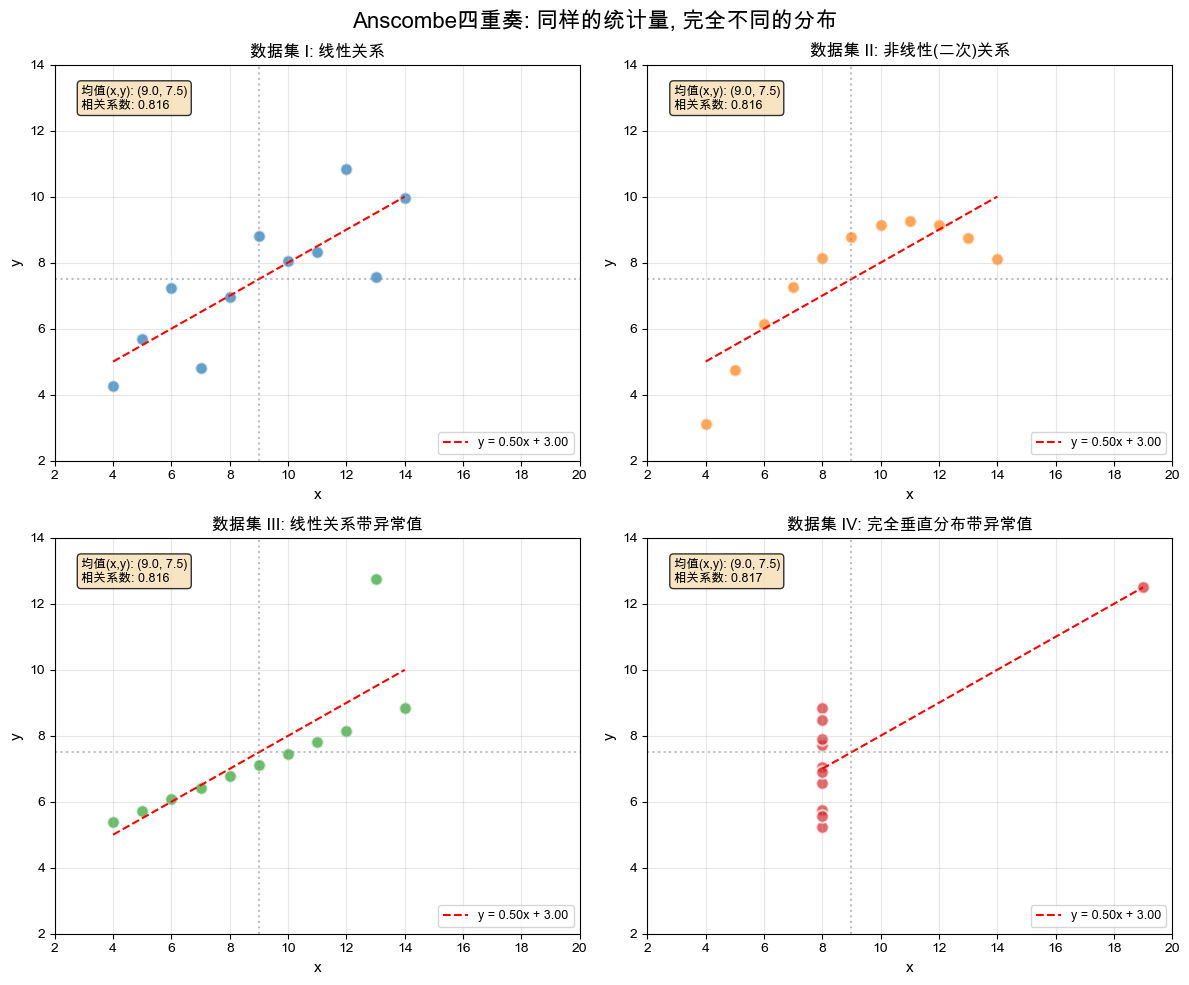

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False

# 创建图形 - 2x2布局
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Anscombe四重奏: 同样的统计量, 完全不同的分布', 
             fontsize=16, fontweight='bold')

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
titles = ['数据集 I: 线性关系', 
          '数据集 II: 非线性(二次)关系', 
          '数据集 III: 线性关系带异常值', 
          '数据集 IV: 完全垂直分布带异常值']

for idx, group in enumerate(['I', 'II', 'III', 'IV']):
    row, col = idx // 2, idx % 2
    ax = axes[row, col]
    
    x = dfs[group]['x']
    y = dfs[group]['y']
    
    # 绘制散点图
    ax.scatter(x, y, color=colors[idx], s=80, alpha=0.7, edgecolors='white', linewidth=1.5)
    
    # 计算并绘制回归线
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    x_range = np.array([min(x), max(x)])
    y_pred = slope * x_range + intercept
    ax.plot(x_range, y_pred, 'r--', label=f'y = {slope:.2f}x + {intercept:.2f}')
    
    # 添加均值线(可选)
    ax.axhline(y=np.mean(y), color='gray', linestyle=':', alpha=0.5)
    ax.axvline(x=np.mean(x), color='gray', linestyle=':', alpha=0.5)
    
    # 设置坐标轴范围, 方便对比
    ax.set_xlim(2, 20)
    ax.set_ylim(2, 14)
    
    # 添加标签和标题
    ax.set_xlabel('x', fontsize=11)
    ax.set_ylabel('y', fontsize=11)
    ax.set_title(titles[idx], fontsize=12, fontweight='bold')
    
    # 在图上添加统计量文本
    stats_text = f'均值(x,y): ({np.mean(x):.1f}, {np.mean(y):.1f})\n相关系数: {r_value:.3f}'
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

## 优化绘图

未安装scienceplots库，使用Matplotlib默认风格并手动配置。
已手动配置近似Nature的样式，并放大字体。
Anscombe四重奏统计量对比（均相同）
数据集 I: x均值=9.00, y均值=7.50, 相关系数=0.816, 回归线: y=0.50x+3.00
数据集 II: x均值=9.00, y均值=7.50, 相关系数=0.816, 回归线: y=0.50x+3.00
数据集 III: x均值=9.00, y均值=7.50, 相关系数=0.816, 回归线: y=0.50x+3.00
数据集 IV: x均值=9.00, y均值=7.50, 相关系数=0.817, 回归线: y=0.50x+3.00


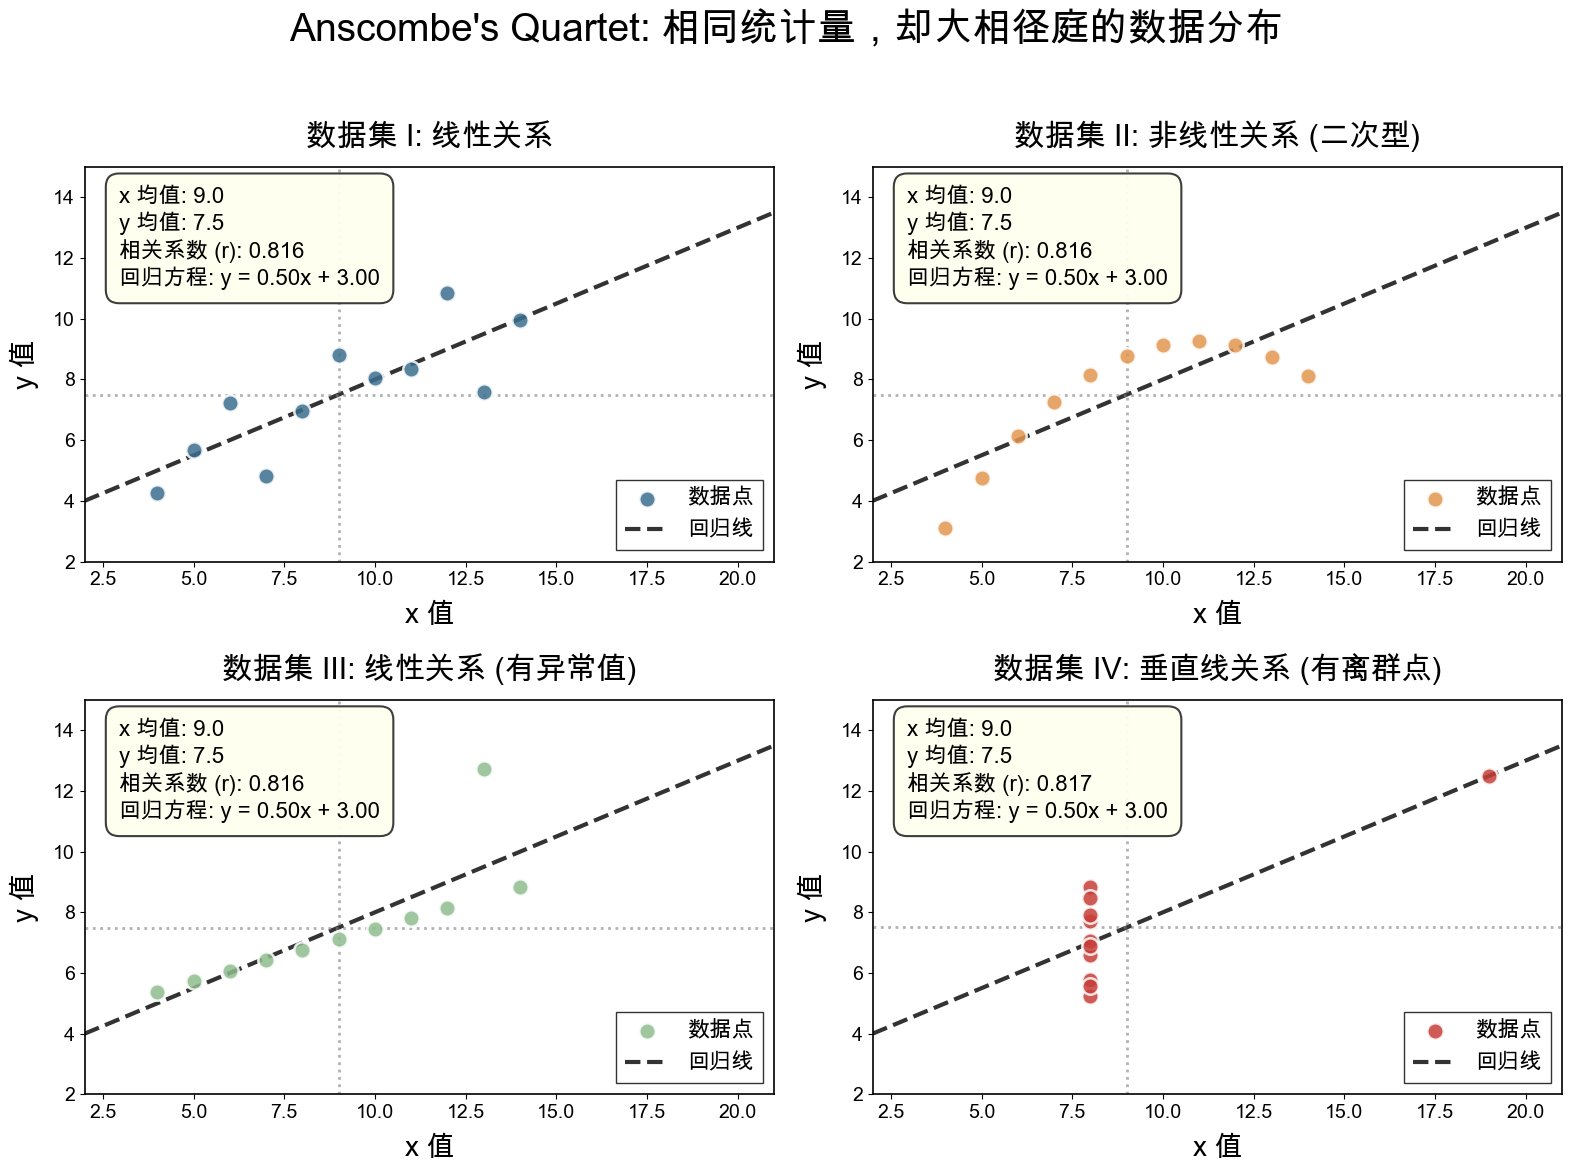

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False

# 尝试导入scienceplots，如果没有安装，则使用备选方案
try:
    import scienceplots
    # 使用Nature期刊风格，并增大全局字体基础大小
    plt.style.use(['science', 'nature', 'no-latex'])
    # 手动覆盖字体大小，确保足够大，适合课堂投影
    plt.rcParams.update({
        'font.size': 16,           # 全局字体大小
        'axes.labelsize': 18,      # 轴标签字体大小
        'axes.titlesize': 20,      # 子图标题字体大小
        'xtick.labelsize': 14,     # X轴刻度字体大小
        'ytick.labelsize': 14,     # Y轴刻度字体大小
        'legend.fontsize': 14,     # 图例字体大小
        'figure.titlesize': 24     # 总标题字体大小
    })
    print("已加载Nature期刊风格，并放大字体。")
except ImportError:
    print("未安装scienceplots库，使用Matplotlib默认风格并手动配置。")
    # 手动配置近似Nature的样式
    plt.rcParams.update({
        'font.size': 16,
        'axes.labelsize': 18,
        'axes.titlesize': 20,
        'xtick.labelsize': 14,
        'ytick.labelsize': 14,
        'legend.fontsize': 14,
        'figure.titlesize': 24,
        'axes.linewidth': 1.2,
        'lines.linewidth': 1.8,
        'grid.alpha': 0.3,
        'grid.linestyle': '--',
    })
    print("已手动配置近似Nature的样式，并放大字体。")


# Anscombe四重奏数据
anscombe_data = {
    'I': {'x': [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5], 
          'y': [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68]},
    'II': {'x': [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5], 
           'y': [9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74]},
    'III': {'x': [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5], 
            'y': [7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73]},
    'IV': {'x': [8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8], 
           'y': [6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89]}
}

# 创建DataFrame
dfs = {}
for group in ['I', 'II', 'III', 'IV']:
    df = pd.DataFrame(anscombe_data[group])
    dfs[group] = df

# 计算统计量（打印部分可保留，用于课堂对比）
print("=" * 70)
print("Anscombe四重奏统计量对比（均相同）")
print("=" * 70)
for group in ['I', 'II', 'III', 'IV']:
    x = dfs[group]['x']
    y = dfs[group]['y']
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    print(f"数据集 {group}: x均值={np.mean(x):.2f}, y均值={np.mean(y):.2f}, 相关系数={r_value:.3f}, 回归线: y={slope:.2f}x+{intercept:.2f}")

# 创建一个稍大的图形，以适应放大后的字体
fig, axes = plt.subplots(2, 2, figsize=(16, 12)) # 增大画布尺寸
fig.suptitle('Anscombe\'s Quartet: 相同统计量，却大相径庭的数据分布', 
             fontsize=28, fontweight='bold', y=0.98) # 放大总标题

# 定义更符合Nature期刊风格的柔和但对比明显的配色
# 使用《自然》期刊常见的色板之一（类似其图表常用的蓝、橙、绿、红）
nature_colors = ['#3B6E8F', '#E2954F', '#8FBC8F', '#C73E3A']
# 对应的子图标题
titles = ['数据集 I: 线性关系', 
          '数据集 II: 非线性关系 (二次型)', 
          '数据集 III: 线性关系 (有异常值)', 
          '数据集 IV: 垂直线关系 (有离群点)']

# 定义坐标轴范围，保证四张图对比尺度一致
x_lim = (2, 21)
y_lim = (2, 15)

# 循环绘制四个子图
for idx, group in enumerate(['I', 'II', 'III', 'IV']):
    row, col = idx // 2, idx % 2
    ax = axes[row, col]
    
    x = dfs[group]['x']
    y = dfs[group]['y']
    
    # 绘制散点图
    ax.scatter(x, y, color=nature_colors[idx], s=140, alpha=0.85, 
               edgecolors='white', linewidth=1.8, zorder=3, label='数据点')
    
    # 计算并绘制回归线
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    x_range = np.array([x_lim[0], x_lim[1]])
    y_pred = slope * x_range + intercept
    # 回归线使用黑色虚线，风格化且清晰
    # ax.plot(x_range, y_pred, color='black', linestyle='--', linewidth=3, 
    #         alpha=0.8, label=f'回归线 (y={slope:.2f}x+{intercept:.2f})')
    ax.plot(x_range, y_pred, color='black', linestyle='--', linewidth=3, 
        alpha=0.8, label=f'回归线')
    
    # 绘制均值线 (可选，用浅灰色增加信息维度)
    ax.axhline(y=np.mean(y), color='gray', linestyle=':', linewidth=2, alpha=0.6)
    ax.axvline(x=np.mean(x), color='gray', linestyle=':', linewidth=2, alpha=0.6)
    
    # 设置坐标轴范围
    ax.set_xlim(x_lim)
    ax.set_ylim(y_lim)
    
    # 设置标签和标题
    ax.set_xlabel('x 值', fontsize=20, labelpad=10)
    ax.set_ylabel('y 值', fontsize=20, labelpad=10)
    ax.set_title(titles[idx], fontsize=22, fontweight='bold', pad=15)
    
    # --- 重点优化：放大子图内的统计信息文本，并放置于左上角 ---
    # 使用更清晰的布局，文本字体放大，背景框更明显
    stats_text = (f'x 均值: {np.mean(x):.1f}\n'
                  f'y 均值: {np.mean(y):.1f}\n'
                  f'相关系数 (r): {r_value:.3f}\n'
                  f'回归方程: y = {slope:.2f}x + {intercept:.2f}')
    
    # 在左上角添加文本框，使用更醒目的字体、背景和边框，确保后排可见
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
            fontsize=16,               # 文本字体显著放大到18号
            verticalalignment='top', 
            horizontalalignment='left',
            family='Arial Unicode MS',
            # weight='semibold',
            bbox=dict(boxstyle='round,pad=0.6', facecolor='ivory', 
                      edgecolor='#333333', alpha=0.95, linewidth=1.5))
    
    # 设置网格（使用Nature风格的淡灰色虚线网格）
    # ax.grid(True, linestyle='--', alpha=0.5, linewidth=1)
    # 确保网格在数据点下方，不干扰阅读
    # ax.set_axisbelow(True)
    
    # 添加图例，字体加大，位置放在右下角避免与文本框冲突
    # 但为避免遮挡回归线，可以放在右下角
    ax.legend(loc='lower right', fontsize=16, frameon=True, 
              fancybox=False, edgecolor='black', shadow=False)

# 自动调整子图参数，使整体布局更加紧凑美观
plt.tight_layout(rect=[0, 0, 1, 0.96]) # 为总标题留出空间
plt.show()